# Notebook 02 — Post-Preprocessing EDA

Validates the output of `src/preprocess.py` before training.
All checks must print **PASS**.

| # | Check | What it proves |
|---|-------|----------------|
| 1 | Array shapes & dtypes | Files saved correctly |
| 2 | Class balance | Semi-supervised split is correct |
| 3 | No remaining NaNs | Imputation is complete |
| 4 | Scaling validation | Scaler was fit on train only |
| 5 | Leakage proof | Val mean ≠ 0 confirms scaler fit on train |
| 6 | Outlier range | No extreme values after scaling |
| 7 | Feature distributions | Visual separation between classes |

In [103]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROC = Path("../data/processed")

X_train = np.load(PROC / "X_train.npy")
X_val   = np.load(PROC / "X_val.npy")
y_train = np.load(PROC / "y_train.npy")
y_val   = np.load(PROC / "y_val.npy")

with open(PROC / "feature_columns.json") as f:
    features = json.load(f)

print("Loaded:")
print(f"  X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"  X_val   : {X_val.shape}  dtype={X_val.dtype}")
print(f"  y_train : {y_train.shape}  dtype={y_train.dtype}")
print(f"  y_val   : {y_val.shape}  dtype={y_val.dtype}")
print(f"  features: {features}")

Loaded:
  X_train : (861401, 6)  dtype=float32
  X_val   : (269062, 6)  dtype=float32
  y_train : (861401,)  dtype=int8
  y_val   : (269062,)  dtype=int8
  features: ['int_rate', 'dti', 'fico_range_low', 'annual_inc', 'loan_amnt', 'revol_util']


In [104]:
results = {}

# ── Check 1: Array shapes & dtypes ────────────────────────────────────────────
n_features = len(features)
c1 = (
    X_train.ndim == 2 and X_train.shape[1] == n_features
    and X_val.ndim == 2 and X_val.shape[1] == n_features
    and X_train.dtype == np.float32
    and X_val.dtype   == np.float32
)
results["1 Shapes & dtypes"] = c1
print(f"Check 1 — Shapes & dtypes     : {'PASS' if c1 else 'FAIL'}")
print(f"         X_train={X_train.shape} X_val={X_val.shape}")

# ── Check 2: Class balance ─────────────────────────────────────────────────────
# train must be 100% normal (label=0); val must contain both classes
c2 = (
    np.all(y_train == 0)
    and len(np.unique(y_val)) == 2
)
results["2 Class balance"] = c2
val_anomaly_pct = y_val.mean() * 100
print(f"\nCheck 2 — Class balance        : {'PASS' if c2 else 'FAIL'}")
print(f"         train unique labels : {np.unique(y_train)}  (expected: [0])")
print(f"         val anomaly rate    : {val_anomaly_pct:.1f}%")

# ── Check 3: No NaNs ──────────────────────────────────────────────────────────
nan_train = np.isnan(X_train).sum()
nan_val   = np.isnan(X_val).sum()
c3 = (nan_train == 0 and nan_val == 0)
results["3 No NaNs"] = c3
print(f"\nCheck 3 — No NaNs              : {'PASS' if c3 else 'FAIL'}")
print(f"         NaNs train={nan_train}  val={nan_val}")

# ── Check 4: Scaling validation ───────────────────────────────────────────────
# train mean ≈ 0, train std ≈ 1 (scaler was fit on train)
train_means = X_train.mean(axis=0)
train_stds  = X_train.std(axis=0)
c4 = (
    np.allclose(train_means, 0, atol=1e-4)
    and np.allclose(train_stds,  1, atol=1e-2)
)
results["4 Scaling validation"] = c4
print(f"\nCheck 4 — Scaling validation   : {'PASS' if c4 else 'FAIL'}")
print(f"         train means : {np.round(train_means, 4)}")
print(f"         train stds  : {np.round(train_stds,  4)}")

# ── Check 5: Leakage proof ────────────────────────────────────────────────────
# If scaler was fit on train only, val means will NOT be exactly 0.
# The deviation proves the val set was not seen during fit.
val_means = X_val.mean(axis=0)
c5 = not np.allclose(val_means, 0, atol=0.01)
results["5 Leakage proof"] = c5
print(f"\nCheck 5 — Leakage proof        : {'PASS' if c5 else 'FAIL'}")
print(f"         val means (should not be ~0): {np.round(val_means, 4)}")

# ── Check 6: Outlier range ────────────────────────────────────────────────────
# After scaling continuous data, values beyond ±6σ are extreme outliers
max_abs_train = np.abs(X_train).max()
max_abs_val   = np.abs(X_val).max()
OUTLIER_THRESHOLD = 6.0
c6 = (max_abs_train <= OUTLIER_THRESHOLD and max_abs_val <= OUTLIER_THRESHOLD)
results["6 Outlier range"] = c6
print(f"\nCheck 6 — Outlier range (≤±{OUTLIER_THRESHOLD}σ) : {'PASS' if c6 else 'FAIL'}")
print(f"         max|x| train={max_abs_train:.3f}  val={max_abs_val:.3f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*50)
all_pass = all(results.values())
for name, result in results.items():
    print(f"  {'PASS' if result else 'FAIL'}  {name}")
print("="*50)
print(f"  Overall: {'ALL PASS — ready to train' if all_pass else 'FAILURES DETECTED — fix before training'}")

Check 1 — Shapes & dtypes     : PASS
         X_train=(861401, 6) X_val=(269062, 6)

Check 2 — Class balance        : PASS
         train unique labels : [0]  (expected: [0])
         val anomaly rate    : 20.0%

Check 3 — No NaNs              : PASS
         NaNs train=0  val=0

Check 4 — Scaling validation   : PASS
         train means : [ 0.  0.  0.  0. -0. -0.]
         train stds  : [1. 1. 1. 1. 1. 1.]

Check 5 — Leakage proof        : PASS
         val means (should not be ~0): [ 0.1337  0.0474 -0.0647 -0.0332  0.0324  0.0261]

Check 6 — Outlier range (≤±6.0σ) : PASS
         max|x| train=4.345  val=4.345

  PASS  1 Shapes & dtypes
  PASS  2 Class balance
  PASS  3 No NaNs
  PASS  4 Scaling validation
  PASS  5 Leakage proof
  PASS  6 Outlier range
  Overall: ALL PASS — ready to train


## Feature Statistics by Class

Compare mean and std of each feature between Fully Paid (0) and Charged Off (1) in the val set.
We expect financially distressed borrowers to show higher `int_rate`, `dti`, lower `fico_range_low`.

In [105]:
df_val = pd.DataFrame(X_val, columns=features)
df_val["label"] = y_val

stats = df_val.groupby("label")[features].agg(["mean", "std"]).round(3)
stats.index = ["Fully Paid (0)", "Charged Off (1)"]
print("Val set statistics (scaled):")
print(stats.to_string())

Val set statistics (scaled):
                int_rate           dti        fico_range_low        annual_inc        loan_amnt        revol_util       
                    mean    std   mean    std           mean    std       mean    std      mean    std       mean    std
Fully Paid (0)    -0.001  1.000 -0.001  0.999         -0.001  0.997     -0.001  1.001    -0.002  0.997     -0.002  1.000
Charged Off (1)    0.672  1.051  0.243  0.954         -0.319  0.792     -0.164  0.978     0.169  1.020      0.140  0.917


## Feature Distributions — Fully Paid vs Charged Off

Overlapping histograms for each of the 6 features in the val set.
Separation between the two distributions is the signal the VAE must learn.

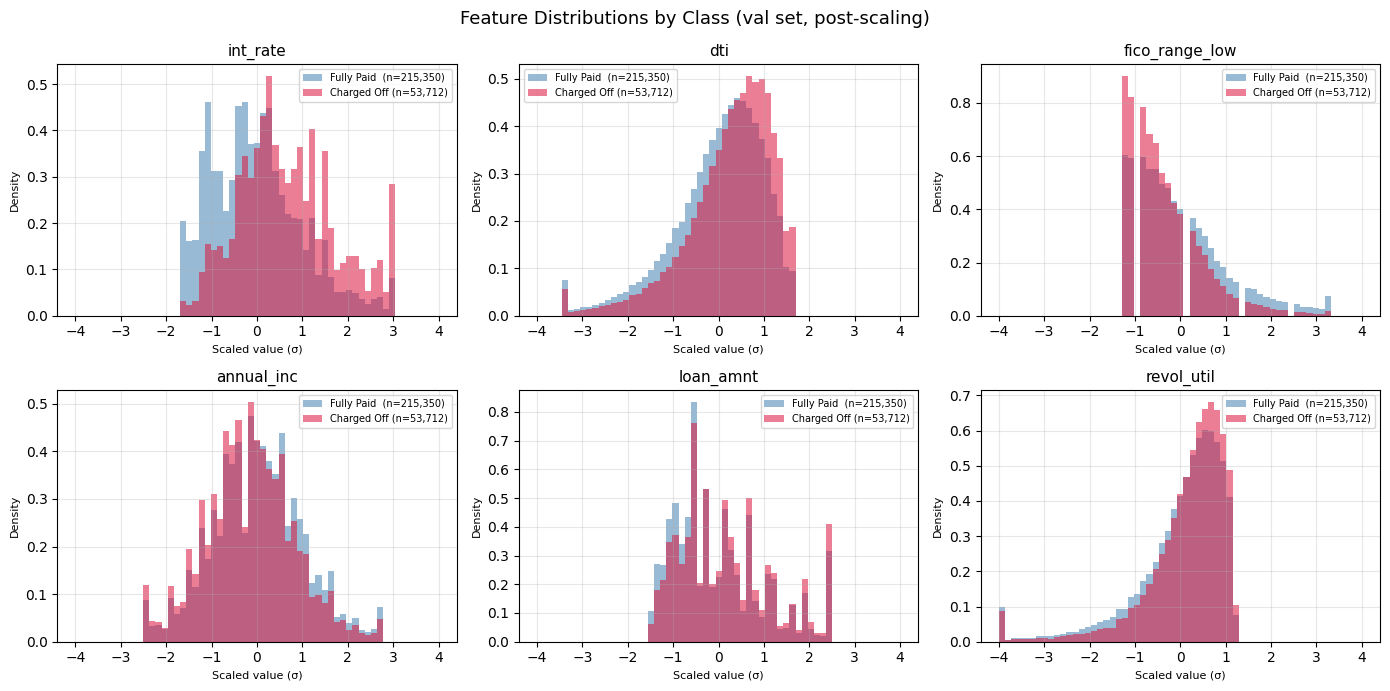

Saved: reports/figures/feature_distributions.png


In [106]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

normal_mask  = y_val == 0
anomaly_mask = y_val == 1

for i, feat in enumerate(features):
    ax = axes[i]
    normal_vals  = X_val[normal_mask,  i]
    anomaly_vals = X_val[anomaly_mask, i]

    # Clip at ±4σ for readability
    clip = 4.0
    bins = np.linspace(-clip, clip, 60)

    ax.hist(normal_vals.clip(-clip, clip),  bins=bins, alpha=0.55,
            density=True, color="steelblue",
            label=f"Fully Paid  (n={normal_mask.sum():,})")
    ax.hist(anomaly_vals.clip(-clip, clip), bins=bins, alpha=0.55,
            density=True, color="crimson",
            label=f"Charged Off (n={anomaly_mask.sum():,})")

    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("Scaled value (σ)", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Feature Distributions by Class (val set, post-scaling)",
    fontsize=13,
)
plt.tight_layout()

import os
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/figures/feature_distributions.png")

## Correlation Matrix

Checks for multicollinearity among the 6 features (train set).
High correlation (>0.8) between two features means one is partially redundant,
which can compress the VAE's effective input dimensionality.

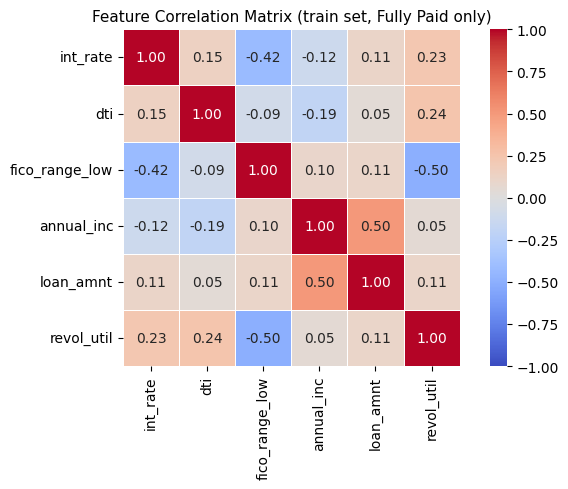

No high-correlation pairs (|r| > 0.7) found.


In [107]:
df_train = pd.DataFrame(X_train, columns=features)
corr = df_train.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Feature Correlation Matrix (train set, Fully Paid only)", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag any high-correlation pairs
high_corr = [
    (features[i], features[j], round(corr.iloc[i, j], 3))
    for i in range(len(features))
    for j in range(i+1, len(features))
    if abs(corr.iloc[i, j]) > 0.7
]
if high_corr:
    print("High correlation pairs (|r| > 0.7):")
    for a, b, r in high_corr:
        print(f"  {a} vs {b} : r={r}")
else:
    print("No high-correlation pairs (|r| > 0.7) found.")